In [1]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
%matplotlib inline
#%matplotlib facilitates plotting matplotlib graphs just below code cells and storing them in the notebook document  

In [3]:
import yfinance as yf
assets = ['SAN.PA', '^FCHI']
pf_data = pd.DataFrame()

for i in assets:
    pf_data[i] = yf.download(i, start = '2010-1-1')['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
pf_data.tail()

,SAN.PA,^FCHI
Date,,
2026-01-06,82.290001,8237.429688
2026-01-07,82.750000,8233.919922
2026-01-08,82.889999,8243.469727
2026-01-09,84.440002,8362.089844
2026-01-12,82.220001,8350.500000


<Axes: xlabel='Date'>

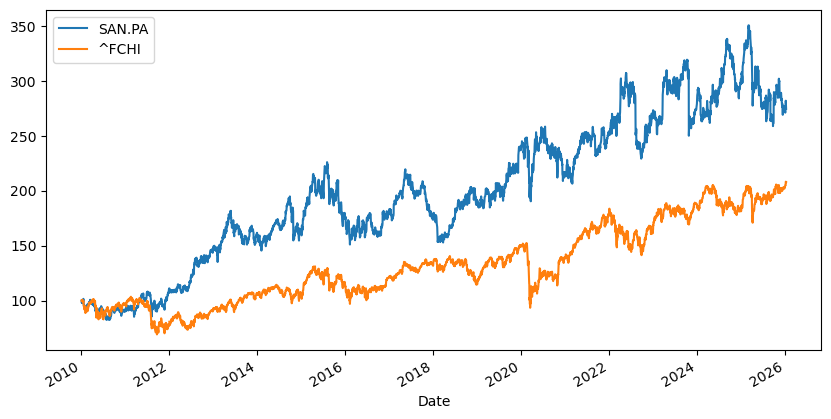

In [8]:
#plot both the data to see how the 2 assets have been performing throughout the time of interest
(pf_data / pf_data.iloc[0] * 100).plot(figsize=(10,5))

In [10]:
#to calculate the efficient frontier we are required first to calculate the log return, average and covariance, correlation matrices

In [11]:
log_returns = np.log(pf_data / pf_data.shift(1))

In [13]:
log_returns.mean() * 250

SAN.PA    0.061603
^FCHI     0.043420
dtype: float64

In [14]:
log_returns.cov() * 250

,SAN.PA,^FCHI
SAN.PA,0.049636,0.025431
^FCHI,0.025431,0.037730


In [15]:
log_returns.corr()

,SAN.PA,^FCHI
SAN.PA,1.000000,0.587295
^FCHI,0.587295,1.000000


In [18]:
num_assets = len(assets)
num_assets
#create a variable that will carry the number of assets in our portfolio

2

In [20]:
#create two random weights and below function helps us to generate random value 0 to 1
arr = np.random.random(2)
arr

array([0.33388582, 0.01041369])

In [25]:
arr[0] + arr [1]

np.float64(0.3442995113591424)

In [23]:
weights = np.random.random(num_assets)
weights /= np.sum(weights)
weights
#this function enables to obtain two randomly generated weights whose sum will always equal one

array([0.90267403, 0.09732597])

In [26]:
weights[0] + weights[1]

np.float64(1.0)

In [27]:
#expected portfolio return:

In [28]:
np.sum(weights * log_returns.mean()) * 250

np.float64(0.059833348664954905)

In [29]:
#expected portfolio variance:

In [30]:
np.dot(weights.T, np.dot(log_returns.cov() * 250, weights))

np.float64(0.045270125297059066)

In [32]:
#expected portfolio volatility:

In [33]:
np.sqrt(np.dot(weights.T, np.dot(log_returns.cov() * 250, weights)))

np.float64(0.2127677731637455)

In [37]:
#we will create a graph where 1000 mean variance simulations will be plotted
#it doesn't mean 1000 different investment composed of different stocks although we are cosidering 1000 combinations of the same two assets 
#sanofi and cac40

In [41]:
pfolio_returns = []
pfolio_volatilities = []

for x in range (1000):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    pfolio_returns.append(np.sum(weights * log_returns.mean()) * 250)
    pfolio_volatilities.append(np.sqrt(np.dot(weights.T, np.dot(log_returns.cov() * 250, weights))))

pfolio_returns,pfolio_volatilities
#in the above last 2 lines of code the key is the a pin method that will add each newly generated portfolio return value to the lowest portfolio
#returns and this operation will be repeated for each pass of the loop until the portfolio returns list accumulates 1000 observation since we are
#calculating expected future portfolio return in the parenthesses, we had to insert the formula np.sum(weights * log_returns.mean()) * 250 and 
#we repeat in the next line the same 

([np.float64(0.05339559715633385),
  np.float64(0.056765506655230766),
  np.float64(0.05403085494726942),
  np.float64(0.043709653578624656),
  np.float64(0.04725880682431621),
  np.float64(0.05300217047139859),
  np.float64(0.052731372648546194),
  np.float64(0.057103159278045205),
  np.float64(0.05216127433735639),
  np.float64(0.053999218056774365),
  np.float64(0.060024181740726386),
  np.float64(0.044684589663482606),
  np.float64(0.05285584019824565),
  np.float64(0.05738063397534233),
  np.float64(0.04486314982310637),
  np.float64(0.0474134036788177),
  np.float64(0.05609837928270631),
  np.float64(0.055649288671269205),
  np.float64(0.04851521401002533),
  np.float64(0.05223441627706959),
  np.float64(0.05186684395672193),
  np.float64(0.054533627742809336),
  np.float64(0.05292913413239055),
  np.float64(0.05026251647797838),
  np.float64(0.04605462736766688),
  np.float64(0.04824030593100976),
  np.float64(0.043630177212131596),
  np.float64(0.04903784502707153),
  np.float6

In [44]:
pfolio_returns = []
pfolio_volatilities = []

for x in range (1000):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    pfolio_returns.append(np.sum(weights * log_returns.mean()) * 250)
    pfolio_volatilities.append(np.sqrt(np.dot(weights.T, np.dot(log_returns.cov() * 250, weights))))

pfolio_returns = np.array(pfolio_returns)
pfolio_volatilities = np.array(pfolio_volatilities)

pfolio_returns, pfolio_volatilities

(array([0.05354098, 0.06058149, 0.05620339, 0.0498657 , 0.05238734,
        0.04962497, 0.04971411, 0.0584404 , 0.05178498, 0.04804652,
        0.04424784, 0.05108648, 0.05342575, 0.05444413, 0.05233967,
        0.05630307, 0.05948985, 0.04363375, 0.05612253, 0.05909487,
        0.04925291, 0.05443996, 0.05190327, 0.05271809, 0.05738686,
        0.05490808, 0.04532095, 0.05225108, 0.0526076 , 0.05132263,
        0.05407574, 0.05265167, 0.05271044, 0.04847376, 0.04904956,
        0.05320308, 0.04703642, 0.05262704, 0.0498825 , 0.05137772,
        0.05580372, 0.05695504, 0.04738367, 0.04627665, 0.05059786,
        0.05286202, 0.05798737, 0.0607276 , 0.05549768, 0.05228722,
        0.04520331, 0.04935314, 0.0514919 , 0.06002956, 0.0490423 ,
        0.0538301 , 0.05512692, 0.04697944, 0.05194869, 0.05433532,
        0.05363447, 0.05379174, 0.0510478 , 0.05841308, 0.05602084,
        0.05031394, 0.05259315, 0.05285269, 0.04502377, 0.05490008,
        0.05503885, 0.04362587, 0.05395067, 0.05

In [45]:
#dataframe object containing two columns one for returns and another one for the respective volatilities. We call this object portfolios
portfolios = pd.DataFrame({'Return' : pfolio_returns, 'Volatility': pfolio_volatilities})

In [46]:
portfolios.head()

,Return,Volatility
0,0.053541,0.188011
1,0.060581,0.216867
2,0.056203,0.196162
3,0.049866,0.183297
4,0.052387,0.185682


In [48]:
portfolios.tail()

,Return,Volatility
995,0.058517,0.206085
996,0.054021,0.189201
997,0.046663,0.185755
998,0.052804,0.186435
999,0.043501,0.193965


Text(0, 0.5, 'Expected Return')

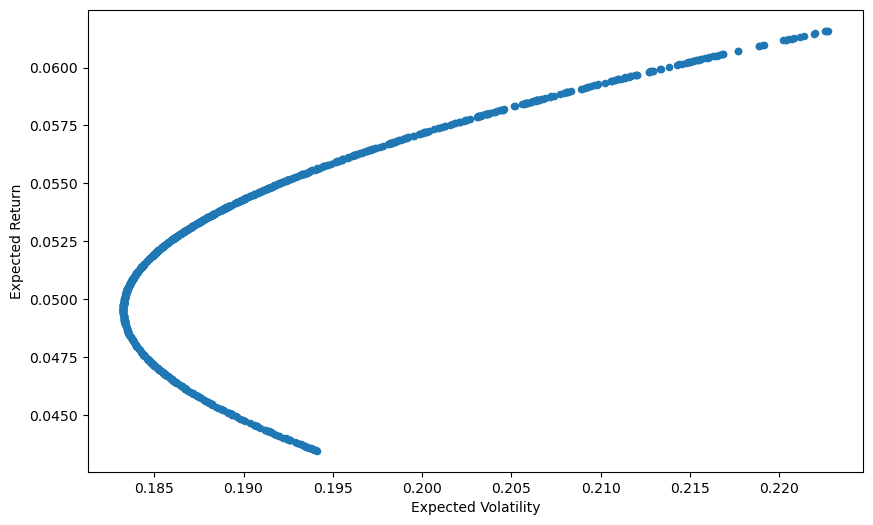

In [50]:
portfolios.plot(x='Volatility', y='Return', kind= 'scatter', figsize = (10, 6));
plt.xlabel ('Expected Volatility')
plt.ylabel ('Expected Return')